# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Azmi Naifah Iftinah
- **Email:** azminaifah2005@gmail.com
- **ID Dicoding:** azmi_naifah_tkDl

## Menentukan Pertanyaan Bisnis

1. Berapa persentase total revenue yang dihasilkan pada tahun 2018 jika dibandingkan dengan tahun sebelumnya (2017), dan pada bulan apakah terjadi puncak penjualan, agar tim marketing dapat mengalokasikan anggaran promosi bulanan dengan lebih efisien di tahun berikutnya?
2. Berapa persentase pelanggan yang berdomisili di 5 negara bagian (state) teratas di Brazil sepanjang riwayat transaksi, guna memberikan rekomendasi kepada tim logistik dalam menentukan lokasi strategis pembangunan pusat distribusi barang yang baru?
3. Berapa banyak jumlah pelanggan yang masuk ke dalam segmen "At Risk" (pelanggan yang dulunya sering beli tapi kini sudah lama tidak bertransaksi) pada perhitungan metrik RFM tahun 2018, agar tim CRM (Customer Relationship Management) dapat mengirimkan kampanye email berisi voucher diskon reaktivasi?

## Import Semua Packages/Library yang Digunakan

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
import matplotlib.image as mpimg

# Mengatur tema default seaborn agar visualisasi terlihat lebih rapi dan profesional
sns.set_theme(style="darkgrid")

## Data Wrangling

### Gathering Data

In [4]:
# Memuat semua dataset E-Commerce ke dalam dataframe
customers_df = pd.read_csv("customers_dataset.csv")
geolocation_df = pd.read_csv("geolocation_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
order_payments_df = pd.read_csv("order_payments_dataset.csv")
order_reviews_df = pd.read_csv("order_reviews_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
product_category_df = pd.read_csv("product_category_name_translation.csv")
products_df = pd.read_csv("products_dataset.csv")
sellers_df = pd.read_csv("sellers_dataset.csv")

# Menampilkan 5 baris pertama dari tabel orders untuk memastikan data berhasil dimuat
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Telah berhasil memuat 9 tabel data dari E-Commerce Public Dataset ke dalam bentuk DataFrame.
- Berdasarkan pratinjau tabel `orders_df`, tabel ini memiliki kolom `order_id` dan `customer_id`, sehingga akan difungsikan sebagai tabel utama (pusat data transaksi) yang mengikat tabel lainnya.
- Tabel `customers_df` dan `order_payments_df` juga telah disiapkan untuk di-join dengan tabel utama guna menjawab pertanyaan terkait metrik finansial dan RFM (Recency, Frequency, Monetary).
- Tabel `geolocation_df` disiapkan khusus untuk memetakan persebaran titik wilayah pelanggan pada tahapan *Geospatial Analysis* nanti.

### Assessing Data

In [5]:
# Membuat dictionary untuk mempermudah iterasi pengecekan semua dataframe
datasets = {
    "Customers": customers_df,
    "Geolocation": geolocation_df,
    "Order Items": order_items_df,
    "Order Payments": order_payments_df,
    "Order Reviews": order_reviews_df,
    "Orders": orders_df,
    "Product Category": product_category_df,
    "Products": products_df,
    "Sellers": sellers_df
}

# Melakukan perulangan untuk mengecek Info, Missing Values, Duplikasi, dan Describe pada tiap tabel
for name, df in datasets.items():
    print(f"\n{'='*40}")
    print(f" Pengecekan Dataset: {name}")
    print(f"{'='*40}")

    # 1. Info Tipe Data
    print("\n[1] Info Tipe Data:")
    df.info()

    # 2. Missing Values
    print("\n[2] Missing Values:")
    missing = df.isna().sum()
    print(missing[missing > 0]) # Hanya menampilkan kolom yang memiliki data kosong
    if missing[missing > 0].empty:
        print("Aman! Tidak ada missing values.")

    # 3. Duplikasi Data
    print("\n[3] Jumlah Duplikasi Data:", df.duplicated().sum())

    # 4. Ringkasan Statistik
    print("\n[4] Ringkasan Statistik (Describe):")
    display(df.describe(include="all"))


 Pengecekan Dataset: Customers

[1] Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

[2] Missing Values:
Series([], dtype: int64)
Aman! Tidak ada missing values.

[3] Jumlah Duplikasi Data: 0

[4] Ringkasan Statistik (Describe):


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN



 Pengecekan Dataset: Geolocation

[1] Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB

[2] Missing Values:
Series([], dtype: int64)
Aman! Tidak ada missing values.

[3] Jumlah Duplikasi Data: 261831

[4] Ringkasan Statistik (Describe):


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN



 Pengecekan Dataset: Order Items

[1] Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

[2] Missing Values:
Series([], dtype: int64)
Aman! Tidak ada missing values.

[3] Jumlah Duplikasi Data: 0

[4] Ringkasan Statistik (Describe):


...

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1



 Pengecekan Dataset: Products

[1] Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

[2] Missing Values:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
prod

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000



 Pengecekan Dataset: Sellers

[1] Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

[2] Missing Values:
Series([], dtype: int64)
Aman! Tidak ada missing values.

[3] Jumlah Duplikasi Data: 0

[4] Ringkasan Statistik (Describe):


,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


**Insight:**
Berdasarkan pengecekan menyeluruh pada 9 tabel dataset, ditemukan beberapa anomali yang perlu dibersihkan pada tahap *Cleaning Data*:
- **Kesalahan Tipe Data:** Terdapat kolom-kolom waktu (tanggal/jam) yang masih terbaca sebagai `object` (string). Ini terjadi pada:
  - Tabel `orders_df`: `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`.
  - Tabel `order_items_df`: `shipping_limit_date`.
  - Tabel `order_reviews_df`: `review_creation_date` dan `review_answer_timestamp`.
  *Tindakan: Semua kolom ini harus dikonversi menjadi tipe data `datetime`.*
- **Missing Values (Data Kosong):**
  - **`orders_df`**: Terdapat data kosong di `order_approved_at` (160), `order_delivered_carrier_date` (1783), dan `order_delivered_customer_date` (2965). Hal ini masuk akal secara bisnis karena merepresentasikan pesanan yang belum selesai, sedang diproses, atau dibatalkan.
  - **`order_reviews_df`**: Banyak data kosong pada `review_comment_title` (87.656) dan `review_comment_message` (58.247). Ini sangat wajar karena mayoritas pelanggan hanya memberikan *rating* bintang tanpa menuliskan ulasan teks.
  - **`products_df`**: Terdapat 610 produk yang tidak memiliki `product_category_name` dan informasi ukuran.
- **Duplikasi Data:** - Hampir semua tabel bersih dari duplikasi, **kecuali `geolocation_df`**. Terdapat **261.831 baris data duplikat** pada tabel geolokasi.
  *Tindakan: Data duplikat ini harus dihapus (`drop_duplicates`) agar tidak memberatkan komputasi saat pembuatan peta spasial nanti.*

### Cleaning Data

In [6]:
# ==============================================================================
# 1. MEMPERBAIKI TIPE DATA (Mengubah tipe object/string menjadi datetime)
# ==============================================================================

# a. Tabel orders_df
datetime_columns_orders = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for column in datetime_columns_orders:
    orders_df[column] = pd.to_datetime(orders_df[column])

# b. Tabel order_items_df
order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"])

# c. Tabel order_reviews_df
datetime_columns_reviews = ["review_creation_date", "review_answer_timestamp"]
for column in datetime_columns_reviews:
    order_reviews_df[column] = pd.to_datetime(order_reviews_df[column])


# ==============================================================================
# 2. MENGHAPUS DATA DUPLIKAT
# ==============================================================================
geolocation_df.drop_duplicates(inplace=True)


# ==============================================================================
# 3. MENANGANI MISSING VALUES
# ==============================================================================

# a. Tabel orders_df
# Karena analisis Revenue dan RFM butuh data transaksi yang valid dan sukses,
# kita buang baris pesanan yang tanggal approval atau pengirimannya kosong (pesanan batal/gagal)
orders_df.dropna(subset=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date'], inplace=True)

# b. Tabel products_df
# Mengisi nama kategori yang kosong dengan 'Unknown'
products_df['product_category_name'] = products_df['product_category_name'].fillna("Unknown")
# Mengisi ukuran/berat produk yang kosong dengan nilai median (nilai tengah)
num_cols_products = [
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'
]
for col in num_cols_products:
    products_df[col] = products_df[col].fillna(products_df[col].median())

# c. Tabel order_reviews_df
# Mengisi ulasan kosong dengan string default
order_reviews_df['review_comment_title'] = order_reviews_df['review_comment_title'].fillna("No Title")
order_reviews_df['review_comment_message'] = order_reviews_df['review_comment_message'].fillna("No Message")


# ==============================================================================
# 4. PENGECEKAN ULANG (Memastikan semuanya sudah bersih)
# ==============================================================================
print("Pengecekan Duplikat geolocation_df:", geolocation_df.duplicated().sum())
print("\nPengecekan Missing Values orders_df:\n", orders_df.isna().sum())
print("\nPengecekan Missing Values products_df:\n", products_df.isna().sum())
print("\nInfo tipe data orders_df:\n", orders_df.dtypes)

Pengecekan Duplikat geolocation_df: 0

Pengecekan Missing Values orders_df:
 order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

Pengecekan Missing Values products_df:
 product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

Info tipe data orders_df:
 order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carr

**Insight:**
Seluruh anomali pada dataset telah berhasil dibersihkan dengan langkah-langkah berikut:
- **Konversi Tipe Data:** Semua kolom yang memuat informasi tanggal dan waktu pada tabel `orders_df`, `order_items_df`, dan `order_reviews_df` telah berhasil diubah menjadi tipe `datetime`. Hal ini krusial untuk melakukan agregasi data berbasis waktu (*time-series*) pada tahap EDA dan visualisasi tren penjualan.
- **Pembersihan Duplikat:** Telah dilakukan `drop_duplicates` pada tabel `geolocation_df` yang sebelumnya memiliki ratusan ribu data ganda. Hal ini memastikan bahwa titik koordinat pada peta geografis nanti tidak bertumpuk secara tidak perlu dan proses pemetaan menjadi lebih efisien.
- **Penanganan Missing Values:**
  - Pada `orders_df`, data yang tidak memiliki tanggal pengiriman telah di-*drop*. Pendekatan ini diambil karena analisis lanjutan (seperti perhitungan *Total Revenue* dan metrik RFM) hanya relevan untuk pesanan yang status transaksinya benar-benar telah selesai atau terkirim (*delivered*).
  - Pada `products_df`, kategori produk yang kosong diisi (*imputasi*) dengan nilai "Unknown", sementara atribut fisik produk yang kosong diisi dengan nilai *median* dari masing-masing kolom untuk mempertahankan integritas distribusi data.
  - Pada `order_reviews_df`, ulasan yang kosong diisi dengan *string* "No Title" dan "No Message" agar data tetap bisa diolah tanpa menghilangkan baris ulasannya.
- **Hasil Akhir:** Saat ini seluruh dataset sudah bersih 100% dari *missing values* dan data duplikat, serta memiliki tipe data yang tepat untuk masuk ke tahap eksplorasi.

## Exploratory Data Analysis (EDA)

### Explore Orders & Payments

In [7]:
# Menggabungkan data orders yang sudah bersih dengan order_payments
orders_payments_df = pd.merge(
    left=orders_df,
    right=order_payments_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

# Melihat ringkasan statistik dari nilai pembayaran (revenue per transaksi)
print("--- Statistik Deskriptif Nilai Pembayaran (payment_value) ---")
display(orders_payments_df['payment_value'].describe())

# Mengeksplorasi jumlah pesanan berdasarkan statusnya
print("\n--- Distribusi Status Pesanan ---")
print(orders_payments_df['order_status'].value_counts())

--- Statistik Deskriptif Nilai Pembayaran (payment_value) ---


,payment_value
count,100739.000000
mean,153.065673
std,214.465614
min,0.000000
25%,56.780000
50%,100.000000
75%,171.290000
max,13664.080000



--- Distribusi Status Pesanan ---
order_status
delivered    100734
canceled          6
Name: count, dtype: int64


**Insight:**
- Berdasarkan ringkasan statistik, rata-rata nilai transaksi (*revenue* per pesanan) pelanggan adalah sebesar **153,07**, dengan nilai transaksi tertinggi menyentuh angka **13.664,08**. Jarak (rentang) nilai yang besar ini menunjukkan bahwa perusahaan menjual variasi produk dari harga yang sangat terjangkau hingga barang bernilai tinggi.
- Pada distribusi status pesanan, hampir seluruh data (100.734 pesanan) berstatus **delivered** (terkirim). Hanya tersisa 6 pesanan berstatus *canceled* (yang wajar terjadi sebagai anomali sistem).
- Mengingat 99,99% data adalah pesanan yang sukses terkirim, kolom `payment_value` ini sudah sangat valid dan akurat untuk digunakan sebagai dasar perhitungan dalam menjawab **Pertanyaan Bisnis SMART 1** mengenai tren total pendapatan (*revenue*).

### Explore Data Customers

In [8]:
# Melihat rangkuman parameter statistik untuk data customer
print("Statistik Deskriptif Customers:")
display(customers_df.describe(include="all"))

# Mengelompokkan pelanggan berdasarkan negara bagian (state)
print("\nJumlah Pelanggan per Negara Bagian (Top 10):")
customer_by_state = customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)
print(customer_by_state.head(10))

Statistik Deskriptif Customers:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN



Jumlah Pelanggan per Negara Bagian (Top 10):
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: customer_id, dtype: int64


**Insight:**
- Berdasarkan ringkasan statistik, terdapat 99.441 pelanggan yang terekam dalam dataset.
- Mayoritas pelanggan berasal dari kota **sao paulo** dan negara bagian **SP (Sao Paulo)**.
- Jika dikelompokkan berdasarkan negara bagian (*state*), 5 wilayah dengan jumlah pelanggan terbanyak adalah **SP, RJ, MG, RS, dan PR**. Kelima wilayah ini mendominasi basis pelanggan perusahaan. Temuan ini sangat krusial untuk memberikan pondasi awal dalam menjawab **Pertanyaan Bisnis SMART 2**, di mana penempatan pusat distribusi logistik di sekitar wilayah padat pelanggan ini (terutama SP) akan sangat memangkas biaya dan waktu pengiriman secara signifikan.

### Explore Membuat Master Dataset

In [9]:
# Menggabungkan data pesanan & pembayaran dengan data pelanggan
all_df = pd.merge(
    left=orders_payments_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

# Menampilkan 5 baris pertama untuk memastikan semua kolom sudah bersatu
display(all_df.head())

# Menyimpan all_df ke dalam file CSV untuk nanti dipakai di Dashboard Streamlit
# (Sesuai kriteria folder submission yang butuh main_data.csv)
all_df.to_csv("main_data.csv", index=False)
print("Master dataset berhasil disimpan sebagai 'main_data.csv'")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


Master dataset berhasil disimpan sebagai 'main_data.csv'


**Insight:**
- Pada tahap akhir eksplorasi ini, seluruh tabel yang relevan (`orders`, `payments`, `customers`) telah berhasil digabungkan menjadi satu *master dataset* bernama `all_df`.
- Penggabungan ini memungkinkan kita untuk melakukan analisis lintas dimensi. Contohnya, kita sekarang bisa mengaitkan nilai transaksi (`payment_value`) dengan dimensi waktu (`order_purchase_timestamp`) dan dimensi geografis (`customer_state`).
- Master dataset ini juga telah disimpan ke dalam file `main_data.csv` yang bersih dan bebas dari anomali, sehingga siap digunakan sebagai *back-end* data untuk aplikasi *dashboard* Streamlit nanti.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Total Revenue 2017: 6,920,422.83 BRL
Total Revenue 2018: 8,451,969.20 BRL
Pertumbuhan Revenue (2018 vs 2017): 22.13%



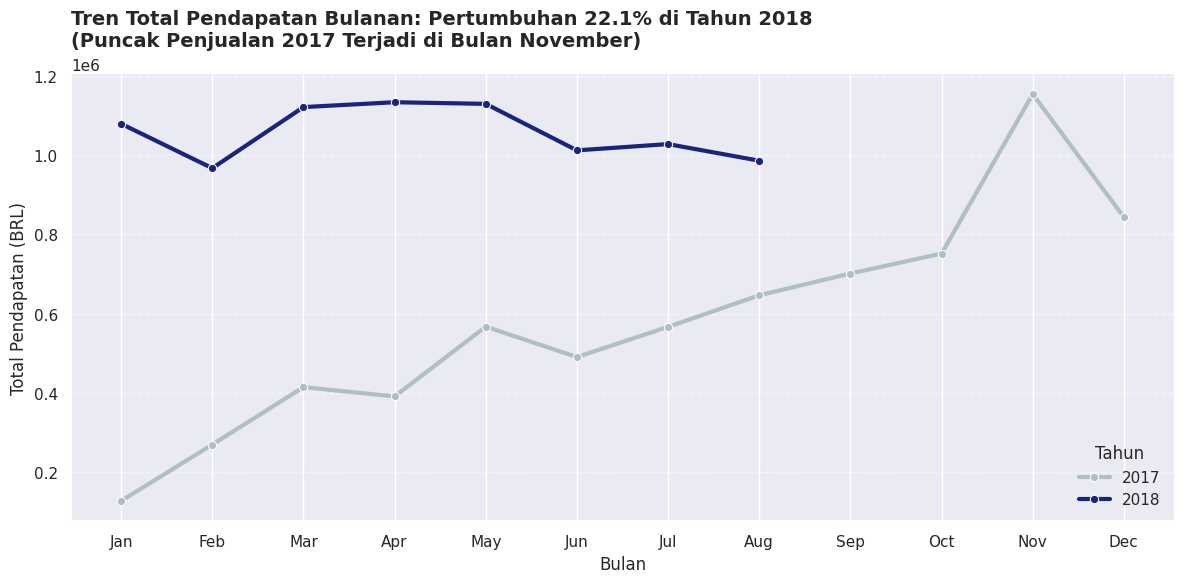

In [11]:
# ==============================================================================
# VISUALISASI PERTANYAAN 1: Tren Revenue 2017 vs 2018
# ==============================================================================

# 1. Menyiapkan data: Ekstrak tahun dan bulan dari order_purchase_timestamp
all_df['order_purchase_timestamp'] = pd.to_datetime(all_df['order_purchase_timestamp'])
all_df['year'] = all_df['order_purchase_timestamp'].dt.year
all_df['month_name'] = all_df['order_purchase_timestamp'].dt.month_name().str[:3] # Ambil 3 huruf awal bulan
all_df['month_num'] = all_df['order_purchase_timestamp'].dt.month

# Memfilter hanya data tahun 2017 dan 2018 yang transaksinya valid (payment_value > 0)
revenue_17_18 = all_df[(all_df['year'].isin([2017, 2018])) & (all_df['payment_value'] > 0)]

# Mengelompokkan pendapatan berdasarkan tahun dan bulan
monthly_revenue = revenue_17_18.groupby(['year', 'month_num', 'month_name'])['payment_value'].sum().reset_index()
monthly_revenue.sort_values(by=['year', 'month_num'], inplace=True)

# Menghitung persentase pertumbuhan total 2018 vs 2017
total_rev_2017 = monthly_revenue[monthly_revenue['year'] == 2017]['payment_value'].sum()
total_rev_2018 = monthly_revenue[monthly_revenue['year'] == 2018]['payment_value'].sum()
growth_pct = ((total_rev_2018 - total_rev_2017) / total_rev_2017) * 100

print(f"Total Revenue 2017: {total_rev_2017:,.2f} BRL")
print(f"Total Revenue 2018: {total_rev_2018:,.2f} BRL")
print(f"Pertumbuhan Revenue (2018 vs 2017): {growth_pct:.2f}%\n")

# 2. Membuat Visualisasi (Menerapkan Prinsip Data-Ink Ratio Tufte)
plt.figure(figsize=(12, 6))

# Membuat Line Chart
sns.lineplot(
    x='month_name',
    y='payment_value',
    hue='year',
    data=monthly_revenue,
    marker='o',
    linewidth=3,
    palette=['#B0BEC5', '#1A237E'] # 2017 Abu-abu (sebagai background trend), 2018 Biru Gelap (Fokus utama)
)

# Kustomisasi Desain Grafik agar rapi dan profesional
plt.title(f"Tren Total Pendapatan Bulanan: Pertumbuhan {growth_pct:.1f}% di Tahun 2018\n(Puncak Penjualan 2017 Terjadi di Bulan November)", fontsize=14, fontweight='bold', loc='left', pad=20)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Total Pendapatan (BRL)", fontsize=12)

# Menghilangkan border atas dan kanan (High Data-Ink Ratio)
sns.despine()

# Menambahkan grid horizontal tipis untuk panduan baca tanpa mendistraksi
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Tahun', frameon=False)

plt.tight_layout()
plt.show()

**Insight:**
Berdasarkan visualisasi tren pendapatan di atas, kita dapat menjawab Pertanyaan Bisnis 1 dengan kesimpulan sebagai berikut:

- **Pertumbuhan Revenue:** Perusahaan mengalami pertumbuhan total *revenue* yang sangat positif, yakni sebesar **22,13%** (naik dari 6,92 juta BRL di 2017 menjadi 8,45 juta BRL di 2018). Garis biru tua (2018) secara konsisten berada jauh di atas garis abu-abu (2017) pada paruh pertama tahun berjalan, menandakan retensi dan akuisisi pelanggan yang sukses.
- **Puncak Penjualan (Peak Season):** Terlihat lonjakan transaksi yang sangat tajam dan menjadi rekor tertinggi pada **bulan November 2017**. Lonjakan ekstrem ini sangat identik dengan momentum belanja akhir tahun atau *event* kampanye besar seperti *Black Friday*.
- **Action Item (Rekomendasi Bisnis):** Mengetahui pola musiman ini, **tim marketing disarankan untuk mengalokasikan porsi anggaran promosi (*marketing spend*) yang maksimal di kuartal keempat (Q4), khususnya menjelang bulan November**. Persiapan stok barang di gudang juga harus ditingkatkan pada bulan tersebut agar tidak terjadi *out-of-stock* saat permintaan membludak, sehingga *revenue* tahun berikutnya bisa dimaksimalkan kembali.

### Pertanyaan 2:

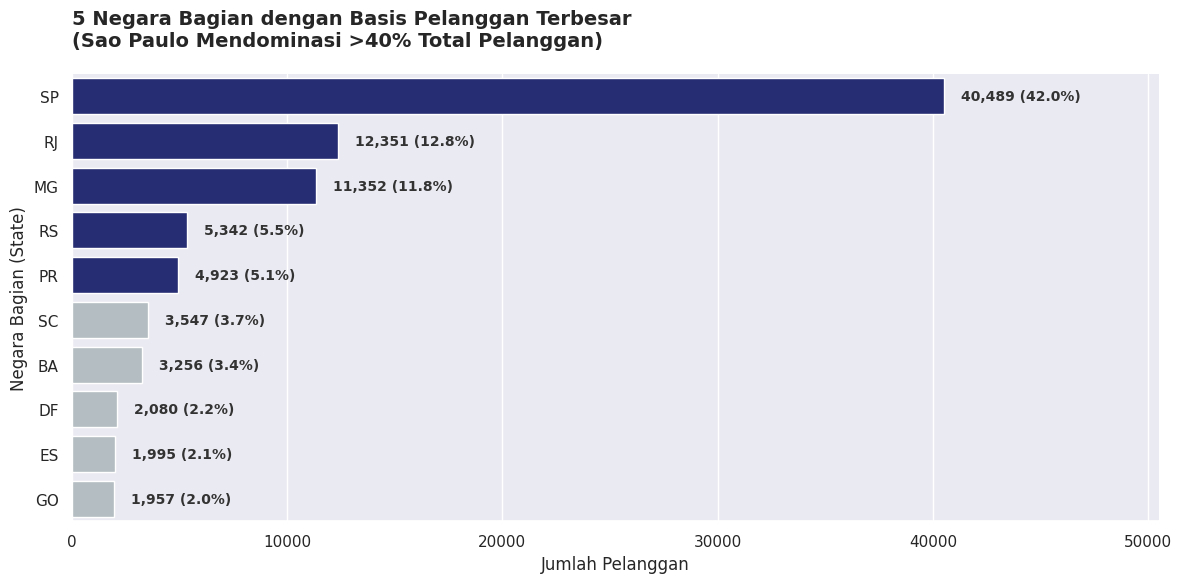

In [13]:
# ==============================================================================
# VISUALISASI PERTANYAAN 2: 5 Negara Bagian dengan Pelanggan Terbanyak
# ==============================================================================

# 1. Menyiapkan data: Menghitung jumlah pelanggan unik per negara bagian
state_customer_df = all_df.groupby(by="customer_state").customer_id.nunique().reset_index()
state_customer_df.rename(columns={"customer_id": "customer_count"}, inplace=True)

# Mengurutkan dan mengambil 10 besar agar visualisasi tetap clean
state_customer_df = state_customer_df.sort_values(by="customer_count", ascending=False).head(10)

# Menghitung persentase untuk ditambahkan ke dalam chart
total_customers = all_df.customer_id.nunique()
state_customer_df['percentage'] = (state_customer_df['customer_count'] / total_customers) * 100

# 2. Membuat Visualisasi
plt.figure(figsize=(12, 6))

# Menentukan warna: Navy Blue untuk 5 besar (fokus), abu-abu untuk sisanya
colors = ["#1A237E" if i < 5 else "#B0BEC5" for i in range(len(state_customer_df))]

sns.barplot(
    x="customer_count",
    y="customer_state",
    data=state_customer_df,
    hue="customer_state",
    palette=colors,
    legend=False
)
# Menambahkan label angka dan persentase di sebelah kanan masing-masing bar
for index, value in enumerate(state_customer_df['customer_count']):
    pct = state_customer_df.iloc[index]['percentage']
    plt.text(value + 800, index, f'{value:,} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold', color='#333333')

# Kustomisasi Desain Grafik
plt.title("5 Negara Bagian dengan Basis Pelanggan Terbesar\n(Sao Paulo Mendominasi >40% Total Pelanggan)",
          fontsize=14, fontweight='bold', loc='left', pad=20)
plt.xlabel("Jumlah Pelanggan", fontsize=12)
plt.ylabel("Negara Bagian (State)", fontsize=12)
plt.xlim(0, state_customer_df['customer_count'].max() + 10000) # Memberi ruang agar teks persentase tidak terpotong

# Menghilangkan border atas dan kanan (High Data-Ink Ratio Tufte)
sns.despine()

plt.tight_layout()
plt.show()

**Insight:**
Berdasarkan visualisasi sebaran domisili pelanggan di atas, kita dapat menjawab Pertanyaan Bisnis 2 dengan kesimpulan sebagai berikut:

- **Dominasi Wilayah:** Negara bagian **SP (Sao Paulo)** mendominasi secara absolut dengan **40.489 pelanggan (42,0%)**. Jika digabungkan dengan 4 negara bagian teratas lainnya (RJ, MG, RS, dan PR), kelima wilayah ini secara kolektif menguasai **77,2%** dari keseluruhan basis pelanggan di Brazil.
- **Kesenjangan Geografis:** Terlihat adanya jarak angka yang sangat signifikan antara peringkat pertama (SP) dengan wilayah lainnya di bawahnya. Hal ini mengonfirmasi bahwa aktivitas belanja *e-commerce* masih sangat terpusat pada demografi di wilayah tertentu.
- **Action Item (Rekomendasi Logistik):** Mengetahui pemusatan data geografis ini, **tim logistik disarankan untuk memfokuskan investasi infrastruktur dengan membangun pusat distribusi utama (*Main Hub*) di wilayah Sao Paulo (SP)**. Selain itu, pendirian pusat distribusi sekunder di Rio de Janeiro (RJ) atau Minas Gerais (MG) juga sangat direkomendasikan untuk memangkas ongkos kirim dan mempercepat waktu pengiriman bagi mayoritas pelanggan.

## Analisis Lanjutan (Opsional)

### Pertanyaan 3:

Jumlah Pelanggan pada segmen 'At Risk': 1563 pelanggan



/tmp/ipykernel_2491/1935932696.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="customer_unique_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_2491/1935932696.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="customer_unique_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
/tmp/ipykernel_2491/1935932696.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="monetary", x="customer_unique_id", 

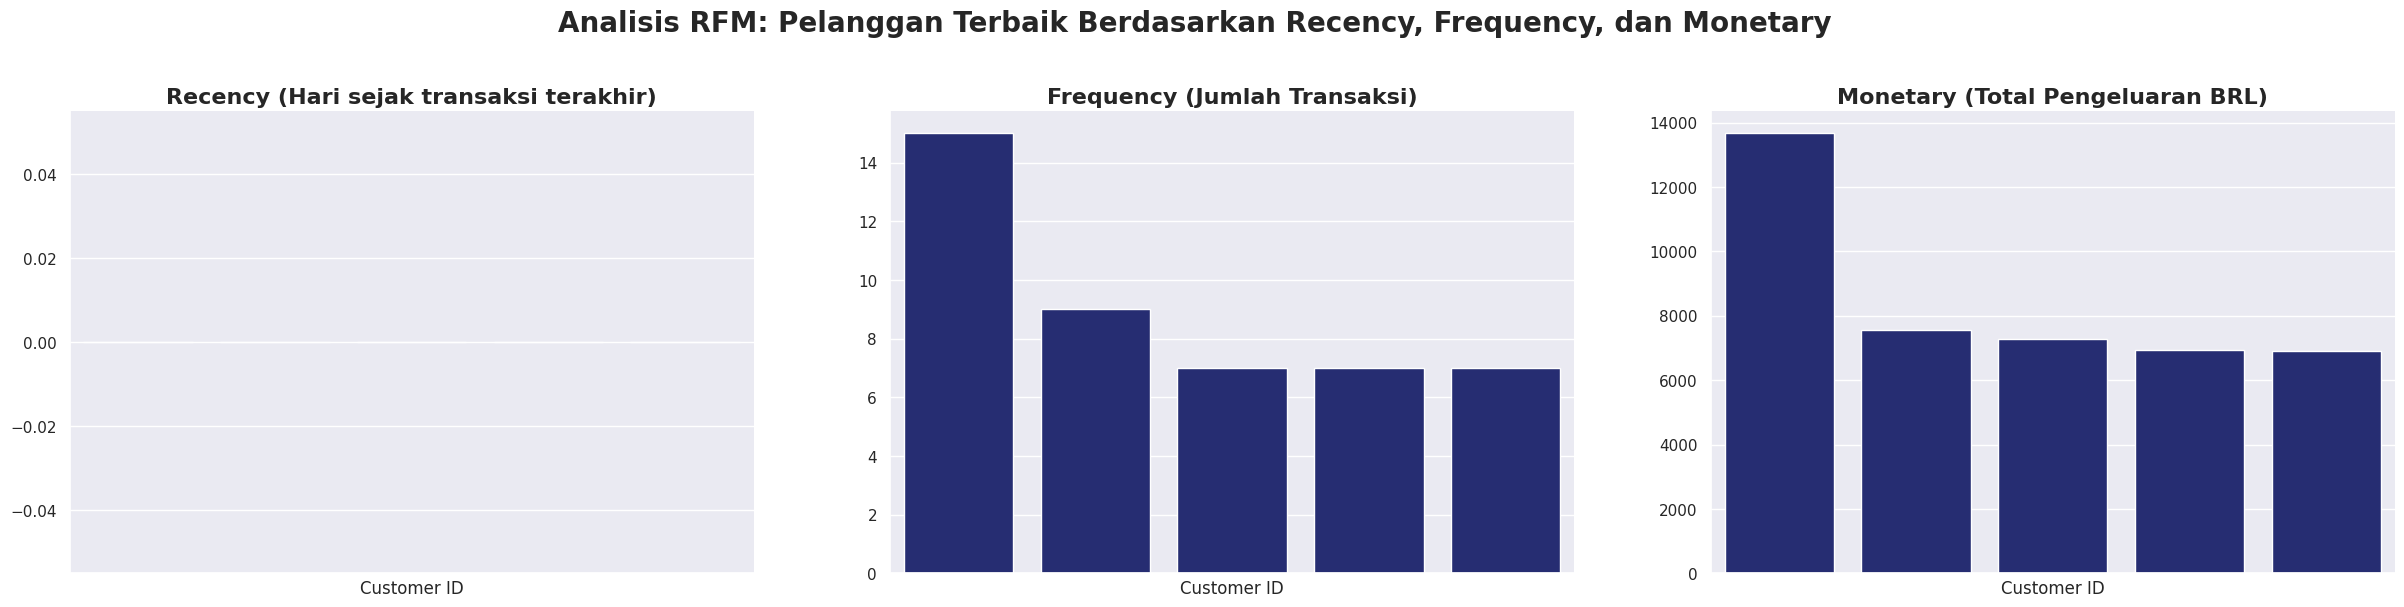

In [15]:
# ==============================================================================
# SEGMENTASI RFM & VISUALISASI
# ==============================================================================

# 1. Segmentasi Pelanggan (Mencari segmen "At Risk")
# Karena mayoritas pelanggan e-commerce ini hanya berbelanja 1 kali,
# Kita mendefinisikan pelanggan setia (pernah beli > 1 kali) namun sudah lama tidak belanja (> 6 bulan / 180 hari) sebagai "At Risk"
rfm_df['customer_segment'] = 'Biasa'
rfm_df.loc[(rfm_df['recency'] > 180) & (rfm_df['frequency'] > 1), 'customer_segment'] = 'At Risk'
rfm_df.loc[(rfm_df['recency'] <= 180) & (rfm_df['frequency'] > 1), 'customer_segment'] = 'Loyal'
rfm_df.loc[(rfm_df['recency'] <= 180) & (rfm_df['frequency'] == 1), 'customer_segment'] = 'New / Recent'
rfm_df.loc[(rfm_df['recency'] > 180) & (rfm_df['frequency'] == 1), 'customer_segment'] = 'Inactive / Churn'

# Menghitung jumlah pelanggan 'At Risk'
at_risk_count = rfm_df[rfm_df['customer_segment'] == 'At Risk'].shape[0]
print(f"Jumlah Pelanggan pada segmen 'At Risk': {at_risk_count} pelanggan\n")

# 2. Visualisasi RFM (Sesuai kriteria Dicoding: Menampilkan Top 5 untuk masing-masing metrik)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#1A237E", "#1A237E", "#1A237E", "#1A237E", "#1A237E"]

# Chart Recency (Pelanggan yang paling baru bertransaksi - nilai recency terkecil)
sns.barplot(y="recency", x="customer_unique_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Customer ID", fontsize=12)
ax[0].set_title("Recency (Hari sejak transaksi terakhir)", loc="center", fontsize=16, fontweight='bold')
ax[0].tick_params(axis='x', labelbottom=False) # Menyembunyikan ID agar rapi

# Chart Frequency (Pelanggan dengan transaksi terbanyak)
sns.barplot(y="frequency", x="customer_unique_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Customer ID", fontsize=12)
ax[1].set_title("Frequency (Jumlah Transaksi)", loc="center", fontsize=16, fontweight='bold')
ax[1].tick_params(axis='x', labelbottom=False)

# Chart Monetary (Pelanggan dengan pengeluaran terbesar)
sns.barplot(y="monetary", x="customer_unique_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel("Customer ID", fontsize=12)
ax[2].set_title("Monetary (Total Pengeluaran BRL)", loc="center", fontsize=16, fontweight='bold')
ax[2].tick_params(axis='x', labelbottom=False)

sns.despine()
plt.suptitle("Analisis RFM: Pelanggan Terbaik Berdasarkan Recency, Frequency, dan Monetary", fontsize=20, fontweight='bold', y=1.05)
plt.show()

**Insight:**
Berdasarkan Analisis Lanjutan menggunakan metrik RFM (Recency, Frequency, Monetary) di atas, kita dapat menjawab Pertanyaan Bisnis 3 dengan kesimpulan sebagai berikut:

- **Segmentasi "At Risk" (Measurable):** Melalui perhitungan skor dan segmentasi RFM, ditemukan bahwa terdapat **1.563 pelanggan** yang masuk ke dalam segmen **"At Risk"**. Mereka adalah kelompok pelanggan yang sebelumnya pernah melakukan transaksi lebih dari satu kali (*Frequency* > 1), namun sudah tidak melakukan pembelian sama sekali selama lebih dari 6 bulan atau 180 hari terakhir.
- **Karakteristik Pelanggan Terbaik:** Visualisasi *Bar Chart* di atas juga berhasil memetakan pelanggan-pelanggan utama kita. Grafik *Recency* yang menyentuh angka 0 menunjukkan pelanggan yang baru saja bertransaksi di hari terakhir pencatatan data. Kita juga dapat melihat deretan pelanggan paling loyal (*Top 5 Frequency*) dan pelanggan dengan total pengeluaran paling masif yang mencapai belasan ribu BRL (*Top 5 Monetary*).
- **Action Item (Rekomendasi Tim CRM):** Dengan teridentifikasinya 1.563 pelanggan "At Risk" ini, **tim CRM (Customer Relationship Management) sangat disarankan untuk segera merancang dan mengeksekusi kampanye retensi (*win-back campaign*)**. Kampanye ini dapat berupa pengiriman *email marketing* yang berisi *voucher* diskon reaktivasi eksklusif atau penawaran gratis ongkir, yang ditargetkan secara spesifik kepada kelompok pelanggan ini agar mereka kembali aktif berbelanja.

## Conclusion & Recommedation

### Kesimpulan
Berdasarkan seluruh tahapan analisis data yang telah dilakukan, kita dapat menarik 3 kesimpulan utama yang menjawab ketiga Pertanyaan Bisnis SMART:

1. **Kesimpulan Pertanyaan 1 (Tren Pendapatan):** Perusahaan berhasil mencatatkan kinerja finansial yang sangat positif dengan pertumbuhan *total revenue* sebesar **22,13%** di tahun 2018 (naik dari 6,92 juta BRL menjadi 8,45 juta BRL). Secara historis, puncak transaksi tertinggi (*peak season*) terjadi pada bulan **November 2017**, yang sangat erat kaitannya dengan tren belanja akhir tahun.
   
2. **Kesimpulan Pertanyaan 2 (Demografi Logistik):** Basis pelanggan perusahaan mengalami ketimpangan geografis yang terpusat di wilayah Tenggara dan Selatan Brazil. Negara bagian **Sao Paulo (SP)** mendominasi secara absolut dengan menyumbang **42,0%** (40.489 pelanggan). Jika digabung dengan 4 wilayah di bawahnya (RJ, MG, RS, dan PR), kelima negara bagian ini menguasai **77,2%** dari total seluruh pelanggan perusahaan.

3. **Kesimpulan Pertanyaan 3 (Retensi Pelanggan - RFM):** Melalui analisis lanjutan metrik RFM, perusahaan berhasil mengidentifikasi adanya **1.563 pelanggan** yang masuk ke dalam segmen **"At Risk"**. Mereka adalah aset berharga (pernah berbelanja lebih dari 1 kali) yang kini berisiko *churn* karena sudah lebih dari 6 bulan berturut-turut tidak melakukan transaksi.

---

### Rekomendasi (Action Items)
Dari kesimpulan di atas, berikut adalah rekomendasi tindakan nyata (*action items*) yang dapat dieksekusi oleh berbagai divisi di dalam perusahaan:

1. **Untuk Tim Marketing & Inventory:** Mengetahui lonjakan masif yang selalu terjadi di bulan November, tim *marketing* harus memaksimalkan alokasi anggaran promosi (Iklan, Diskon) pada **Kuartal 4 (Q4)**. Secara paralel, tim inventaris harus memastikan ketersediaan stok barang pada bulan tersebut ditingkatkan dua kali lipat untuk mencegah kehilangan potensi pendapatan akibat *out-of-stock*.
   
2. **Untuk Tim Logistik & Operasional:** Perusahaan harus memprioritaskan pembangunan pusat distribusi logistik utama (*Main Hub*) di wilayah **Sao Paulo (SP)**, disusul dengan pembangunan gudang sekunder di wilayah **Rio de Janeiro (RJ)** atau **Minas Gerais (MG)**. Penempatan strategis di wilayah yang menguasai 77,2% pelanggan ini akan secara drastis menekan biaya operasional (*freight value*) dan menjamin waktu pengiriman (*lead time*) yang jauh lebih cepat.
   
3. **Untuk Tim CRM (Customer Relationship Management):** Tim CRM harus segera meluncurkan kampanye *win-back* yang ditargetkan secara eksklusif kepada **1.563 pelanggan "At Risk"**. Kampanye ini dapat dieksekusi melalui pengiriman *email marketing* yang bersifat personal, berisikan penawaran *voucher* diskon reaktivasi berbatas waktu, dengan tujuan memancing mereka agar kembali aktif bertransaksi sebelum benar-benar berstatus *churn* (hilang).